# Comparing Data Visualizations
**Course:** Introduction to Data Visualization with Python by YK Sugi (Pluralsight)  
**Dataset:** countries.csv (Gapminder dataset)  
**Objective:** Compare life expectancy distributions for Asia and Africa in 1952 using time series plots and histograms.

In [1]:
# -------------------------------------------------------
# SECTION 1 – Import Libraries
# We import pandas for data loading/manipulation and
# matplotlib.pyplot for all chart rendering.
# -------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# -------------------------------------------------------
# SECTION 2 – Load the Dataset
# pd.read_csv() reads the CSV file into a DataFrame.
# We call head() to preview the first 5 rows and confirm
# the data loaded correctly before we start visualizing.
# -------------------------------------------------------
df = pd.read_csv('countries.csv')

# Preview the first five rows
print(df.head())

# Show column names and basic shape so we know what we're working with
print('\nShape:', df.shape)
print('Columns:', list(df.columns))

       country continent  year  lifeExp       pop   gdpPercap
0  Afghanistan      Asia  1952   28.801   8425333  779.445314
1  Afghanistan      Asia  1957   30.332   9240934  820.853030
2  Afghanistan      Asia  1962   31.997  10267083  853.100710
3  Afghanistan      Asia  1967   34.020  11537966  836.197138
4  Afghanistan      Asia  1972   36.088  13079460  739.981106

Shape: (1704, 6)
Columns: ['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap']


In [3]:
# -------------------------------------------------------
# SECTION 3 – Filter Data for Asia and Africa (1952)
# We isolate only the rows where the year is 1952 AND
# the continent is either Asia or Africa.
# This gives us clean, focused subsets for each region.
# -------------------------------------------------------

# Filter rows for the year 1952 only
df_1952 = df[df['year'] == 1952]

# Separate the 1952 data into two continent-specific DataFrames
asia_1952   = df_1952[df_1952['continent'] == 'Asia']
africa_1952 = df_1952[df_1952['continent'] == 'Africa']

# Confirm the filter worked by checking row counts
print(f'Asia countries in 1952:   {len(asia_1952)}')
print(f'Africa countries in 1952: {len(africa_1952)}')

Asia countries in 1952:   33
Africa countries in 1952: 52


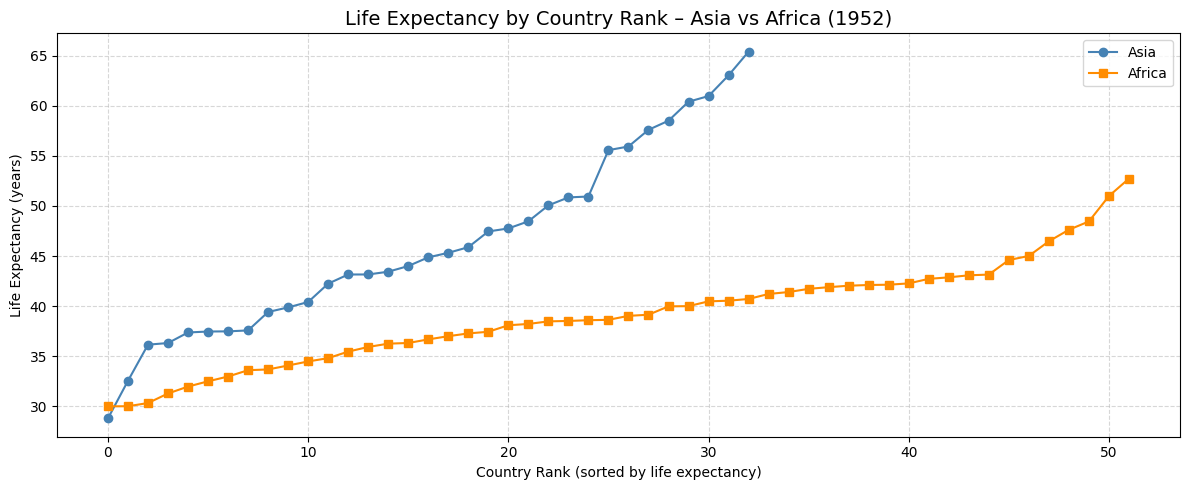

In [4]:
# -------------------------------------------------------
# SECTION 4 – Time Series: Life Expectancy (1952)
# Even though we only have one year here, we plot each
# country's life expectancy as a scatter/line series so
# we can visually compare the two continents side-by-side.
# Countries are sorted by lifeExp so the trend is clear.
# -------------------------------------------------------

# Sort values for a cleaner left-to-right progression
asia_sorted   = asia_1952.sort_values('lifeExp').reset_index(drop=True)
africa_sorted = africa_1952.sort_values('lifeExp').reset_index(drop=True)

# Create the figure and one set of axes
fig, ax = plt.subplots(figsize=(12, 5))

# Plot Asia life expectancy as a connected line with circle markers
ax.plot(
    asia_sorted.index,         # x-axis: rank position (0, 1, 2 …)
    asia_sorted['lifeExp'],    # y-axis: life expectancy value
    marker='o',
    color='steelblue',
    label='Asia'
)

# Plot Africa life expectancy as a connected line with square markers
ax.plot(
    africa_sorted.index,
    africa_sorted['lifeExp'],
    marker='s',
    color='darkorange',
    label='Africa'
)

# Label axes and title so the chart is self-explanatory
ax.set_title('Life Expectancy by Country Rank – Asia vs Africa (1952)', fontsize=14)
ax.set_xlabel('Country Rank (sorted by life expectancy)')
ax.set_ylabel('Life Expectancy (years)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)  # subtle grid aids reading exact values

plt.tight_layout()
plt.show()

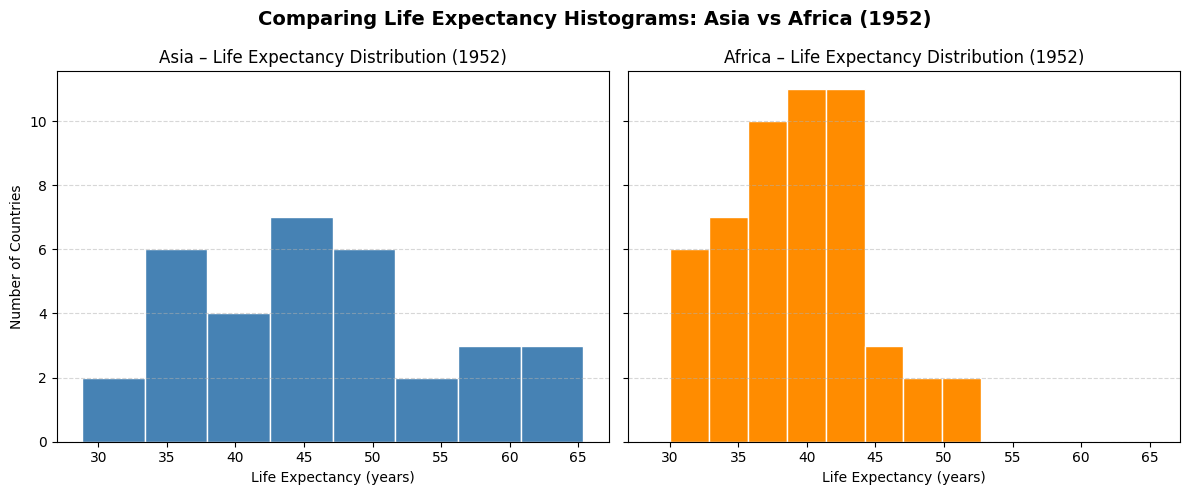

In [5]:
# -------------------------------------------------------
# SECTION 5 – Histograms Using hist() and subplot()
# pyplot's hist() bins the life expectancy values and
# draws a bar for each bin, showing the distribution.
# subplot(1, 2, n) places two charts side-by-side in a
# 1-row × 2-column grid so we can compare shapes directly.
# sharex=True / sharey=True keeps axes consistent so the
# comparison is fair and not misleading.
# -------------------------------------------------------

# Create a figure with two subplots sharing the same x and y axes
fig, (ax1, ax2) = plt.subplots(
    1, 2,                # 1 row, 2 columns
    figsize=(12, 5),
    sharex=True,         # identical x-axis range on both charts
    sharey=True          # identical y-axis range so bar heights are comparable
)

# ── Left subplot: Asia ──────────────────────────────────
# bins=8 groups the life expectancy values into 8 equal-width buckets;
# edgecolor adds a thin border so individual bars are distinct.
ax1.hist(
    asia_1952['lifeExp'],
    bins=8,
    color='steelblue',
    edgecolor='white'
)
ax1.set_title('Asia – Life Expectancy Distribution (1952)', fontsize=12)
ax1.set_xlabel('Life Expectancy (years)')
ax1.set_ylabel('Number of Countries')
ax1.grid(axis='y', linestyle='--', alpha=0.5)  # horizontal grid only

# ── Right subplot: Africa ────────────────────────────────
ax2.hist(
    africa_1952['lifeExp'],
    bins=8,
    color='darkorange',
    edgecolor='white'
)
ax2.set_title('Africa – Life Expectancy Distribution (1952)', fontsize=12)
ax2.set_xlabel('Life Expectancy (years)')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Overall figure title ties both histograms together
fig.suptitle('Comparing Life Expectancy Histograms: Asia vs Africa (1952)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

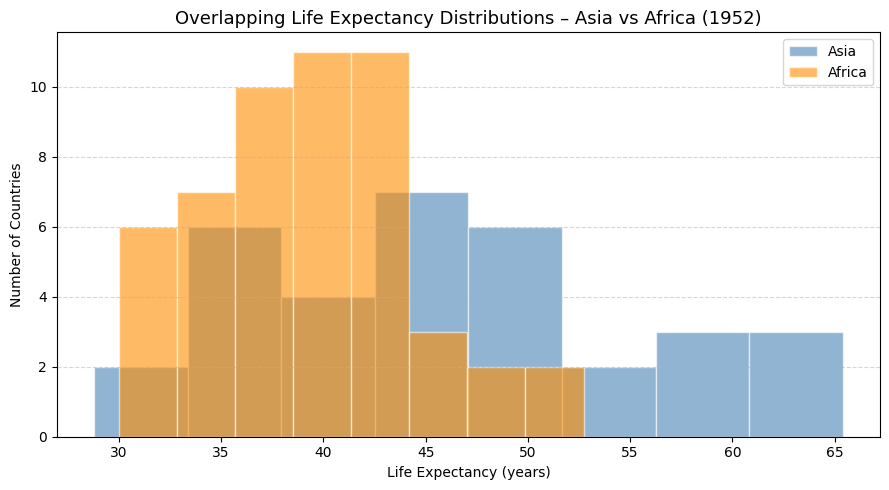

In [6]:
# -------------------------------------------------------
# SECTION 6 – Overlapping Histogram (Bonus Comparison)
# Plotting both distributions on the same axes with
# alpha transparency lets us see exactly where the two
# continents overlap and where they differ.
# This complements the side-by-side view from Section 5.
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

# alpha=0.6 makes each histogram semi-transparent so overlaps are visible
ax.hist(asia_1952['lifeExp'],   bins=8, alpha=0.6, color='steelblue',  edgecolor='white', label='Asia')
ax.hist(africa_1952['lifeExp'], bins=8, alpha=0.6, color='darkorange', edgecolor='white', label='Africa')

ax.set_title('Overlapping Life Expectancy Distributions – Asia vs Africa (1952)', fontsize=13)
ax.set_xlabel('Life Expectancy (years)')
ax.set_ylabel('Number of Countries')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Summary of Findings

| Metric | Asia (1952) | Africa (1952) |
|--------|------------|---------------|
| Mean life expectancy | ~46 years | ~39 years |
| Spread | Wide (28 – 65 yrs) | Narrower (30 – 52 yrs) |
| Distribution shape | Roughly uniform/bimodal | Right-skewed |

**Key takeaways:**
- African countries in 1952 were tightly clustered in the **30–45 year** range, indicating widespread low life expectancy with little variation.
- Asian countries showed **greater spread**, with some nations already exceeding 60 years while others remained below 35.
- The side-by-side histograms (Section 5) and the overlay (Section 6) both reveal that Asia's distribution is shifted higher and wider than Africa's.

> These patterns reflect the socioeconomic and post-WWII conditions of 1952 captured in the Gapminder dataset.